In [1]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    
sns.set_theme(style="white")
work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.evaluators import CompareModels, ModelEvaluator
from scripts.plot_function import *
plot_path = 'M:\\1confiProj\\Analysis\\output\\'

device is : cpu


In [2]:
### prepare model simulation data
m_label = 'with_dn'
m_lst= [2]
ev=ModelEvaluator(m_label)
df_sim_lst = []

for m_id in m_lst:
    df_m_sim = ev.get_allsub_pred_data(m_id=m_id, save_csv=False)
    df_sim_lst.append(df_m_sim)

df_sim = pd.concat(df_sim_lst, ignore_index=True)

### prepare behavior data
df_beh = ev.dh.get_allsub_beh_data()

Model 2 subjects: 100%|██████████| 8/8 [00:02<00:00,  3.90subject/s]


# Behavioural Analysis

## 1. Localization raw data

### Sub-level

In [ ]:
def add_counts(df, ax, xloc, yloc,color):
    counts = df.groupby('AudLoc').size()
    for audloc, count in counts.items():
        ax.annotate(f'{count}', xy=(audloc+xloc, yloc), xytext=(0, 5), textcoords='offset points', ha='center', fontsize=12, color=color)
def add_avg_line(df, ax,color, resp_var='RespLoc'):
    avg_response = df.groupby('AudLoc')[resp_var].mean().reset_index()
    ax.plot(avg_response['AudLoc'], avg_response[resp_var], color=color, linewidth=1,alpha=0.7)

In [ ]:
def plot_raw_rep_sub(df, sub_id, rel, ax, visloc, palette, resp_var='RespLoc', modality='A', legend=True, offset = 1, avg_line=False, n_case = True):
    df_plot = df[(df['Modality'] == modality)&(df.VisRelLabel==rel)&(df.sub_id == sub_id)]

    # Congruent condition
    df_same = df_plot[df_plot.AudLoc == df_plot.VisLoc]
    ax.plot(df_same['AudLoc'], df_same[resp_var], 'o', color='red', markersize=2, alpha=0.7, label='Congruent')

    # Congruent condition
    df_vis = df_plot[df_plot.VisLoc == visloc]
    ax.plot(df_vis['AudLoc'] + offset, df_vis[resp_var], 'o', color=palette[visloc], markersize=2, alpha=0.7, label=f'Visual Stimulus Location = {visloc}')
    
    if avg_line:
        add_avg_line(df=df_same, ax=ax, color = 'red', resp_var=resp_var)
        add_avg_line(df=df_vis, ax=ax, color = palette[visloc], resp_var=resp_var)
    if n_case:
        add_counts(df=df_same, ax=ax, xloc=0, yloc=15.5, color='red')
        add_counts(df=df_vis, ax=ax, xloc=0, yloc=14, color=palette[visloc])
    
    if resp_var=='RespLoc':
        # add the reference lines
        ax.plot([-10, 10], [-10, 10], '--', color='red', linewidth=1, alpha=0.6, zorder=0)
        ax.hlines(y=visloc, xmin=-10, xmax=10, color=palette[visloc], linestyle='--', linewidth=1)

    if visloc!=0:
        df_vism = df_plot[df_plot.VisLoc == -visloc]
        ax.plot(df_vism['AudLoc'] - offset, df_vism[resp_var], 'o', color=palette[-visloc], markersize=2, alpha=0.7, label=f'Visual Stimulus Location = -{visloc}')
        if resp_var=='RespLoc':
            ax.hlines(y=-visloc, xmin=-10, xmax=10, color=palette[-visloc], linestyle='--', linewidth=1)

        if avg_line:
            add_avg_line(df=df_vism, ax=ax, color=palette[-visloc], resp_var=resp_var)
        if n_case:
            add_counts(df=df_vism, ax=ax, xloc=0, yloc=-16, color=palette[-visloc])

    if legend:
        ax.legend(frameon=False, ncol=2,fontsize=fontsize-2, loc='lower center', bbox_to_anchor=(0.9, -0.55))

    clean_axs(ax)

    ax.set_xlabel('Sound Location ($^\\circ$)', fontsize=fontsize)
    ## Autoscale first
    ax.xaxis.set_major_locator(MultipleLocator(5))
    if resp_var=='RespLoc':
        ax.set_aspect('equal', adjustable='box')
        ax.yaxis.set_major_locator(MultipleLocator(5))
        
    #ax.set_ylabel('Response Location', fontsize=12)

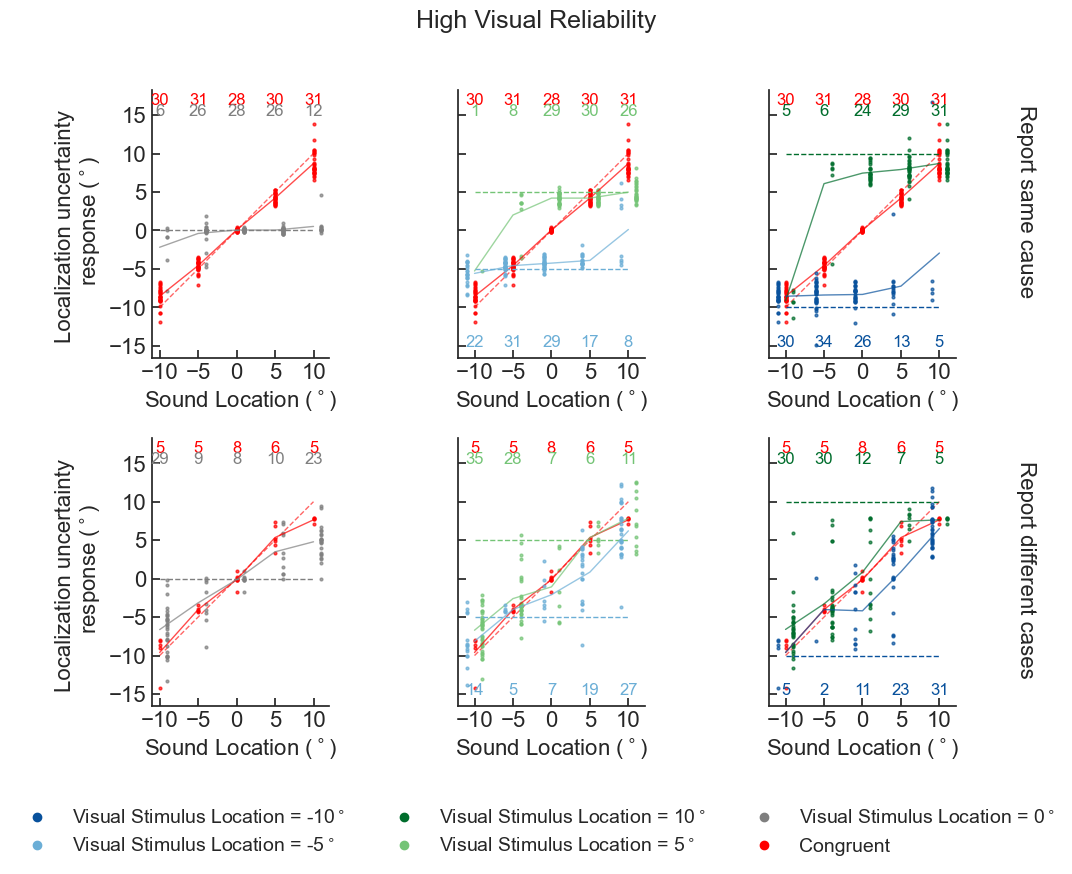

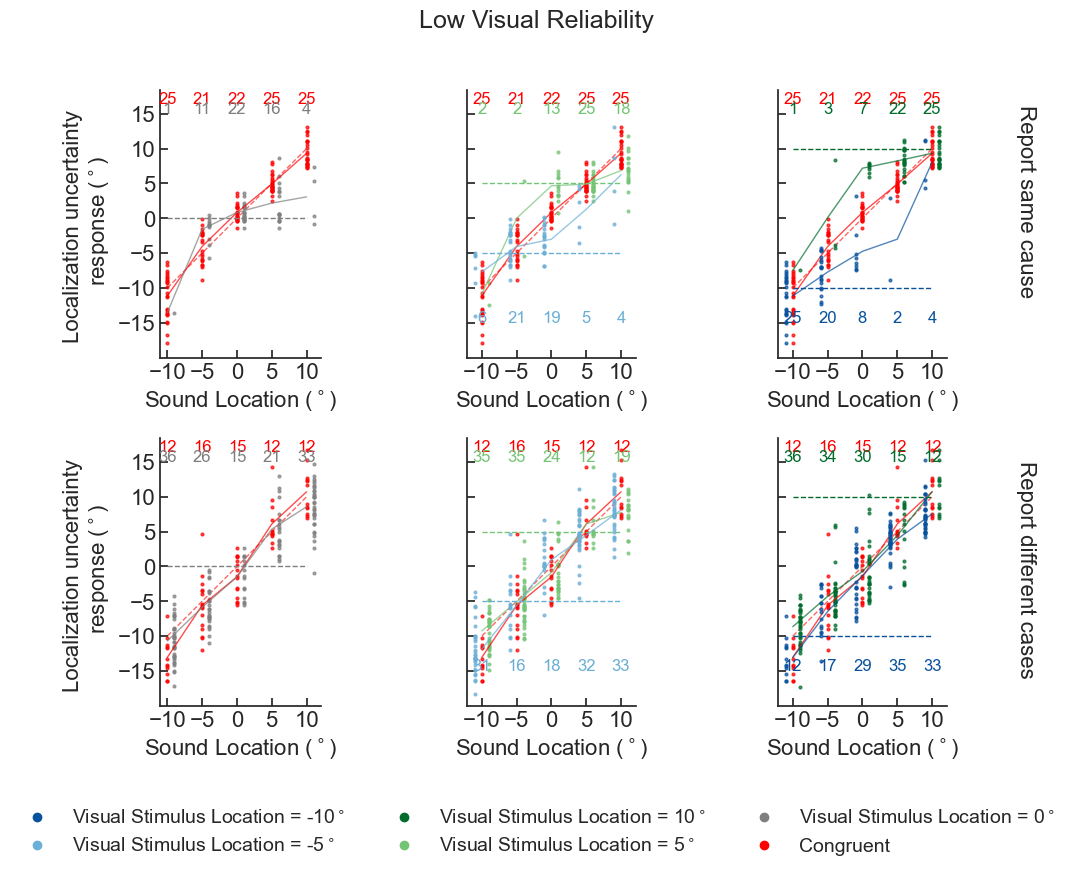

In [ ]:
sub_id= 11

for vrel in ['High', 'Low']:
    fig, axs = plt.subplots(
        nrows=2, ncols=3,
        figsize=(12, 8),
        sharey=True,
        gridspec_kw={'wspace': 0.01, 'hspace': 0.3}
    )
    for row, sources in enumerate([1, 2]):
        for col, visloc in enumerate([0, 5, 10]):
            plot_raw_rep_sub(
                df=df_beh.loc[df_beh.Sources==sources], 
                sub_id=sub_id, 
                rel=vrel, 
                ax=axs[row,col], 
                visloc=visloc, 
                legend=False, 
                avg_line=True,
                palette=palette_vloc
            )

    legend_elements = [
        Line2D(
            [0], [0],
            linestyle='None',
            marker='o',
            markersize=6,
            markerfacecolor=palette_vloc[vloc],
            markeredgecolor=palette_vloc[vloc],
            label=f"Visual Stimulus Location = {vloc}$^\\circ$"
        )
        for vloc in [-10, -5, 10, 5, 0]
    ]
    axs[1,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
    axs[0,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
    legend_elements.append(
        Line2D(
            [0], [0],
            linestyle='None',
            marker='o',
            markersize=6,
            markerfacecolor='red',
            markeredgecolor='red',
            label="Congruent",
        )
    )

    fig.legend(
        handles=legend_elements,
        frameon=False,
        ncol=3,
        fontsize=fontsize-2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )
    
    fig.suptitle(f'{vrel} Visual Reliability', fontsize=fontsize+2)
    fig.text(
        0.9, 0.74, 'Report same cause',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    fig.text(
        0.9, 0.28, 'Report different cases',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    plt.savefig(os.path.join(plot_path, 'sub_select',  f'sub_{sub_id}_raw_rep_plot_vis_{vrel}.png'), bbox_inches='tight', dpi=300)

### All sub (mean)

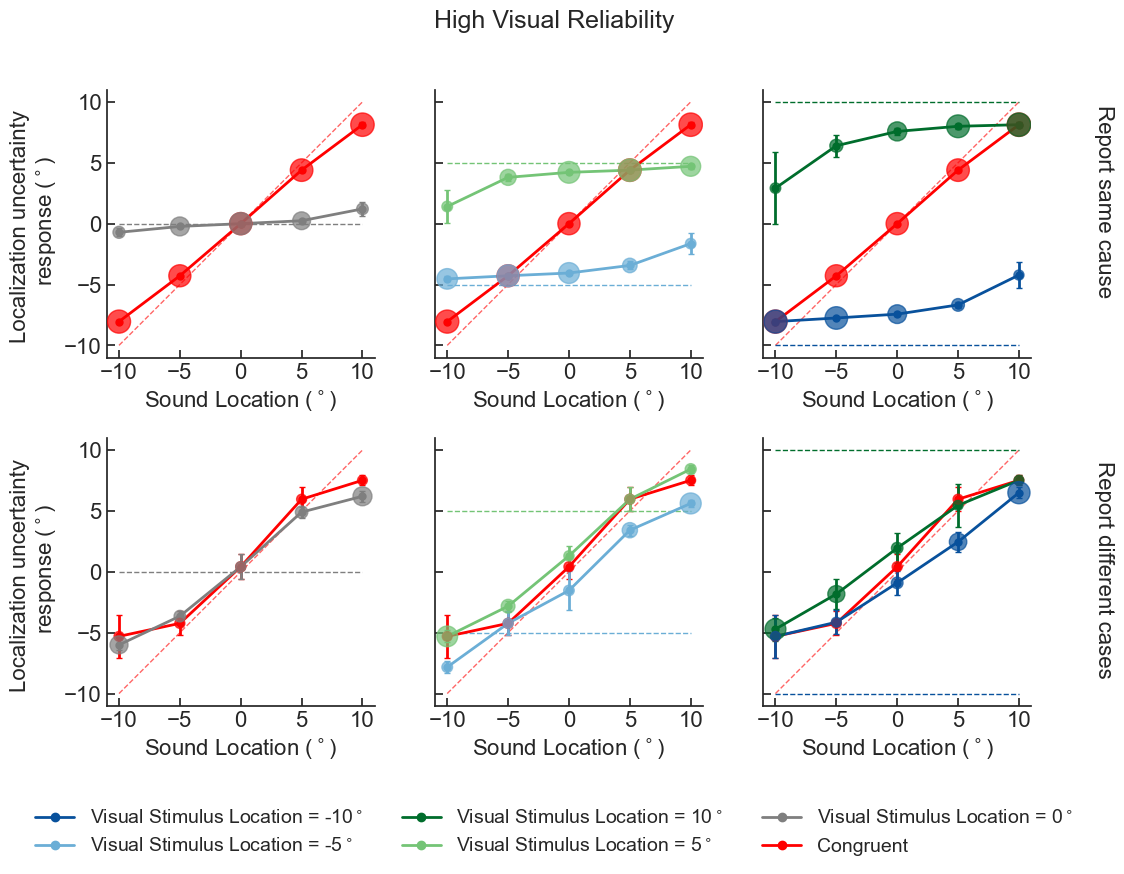

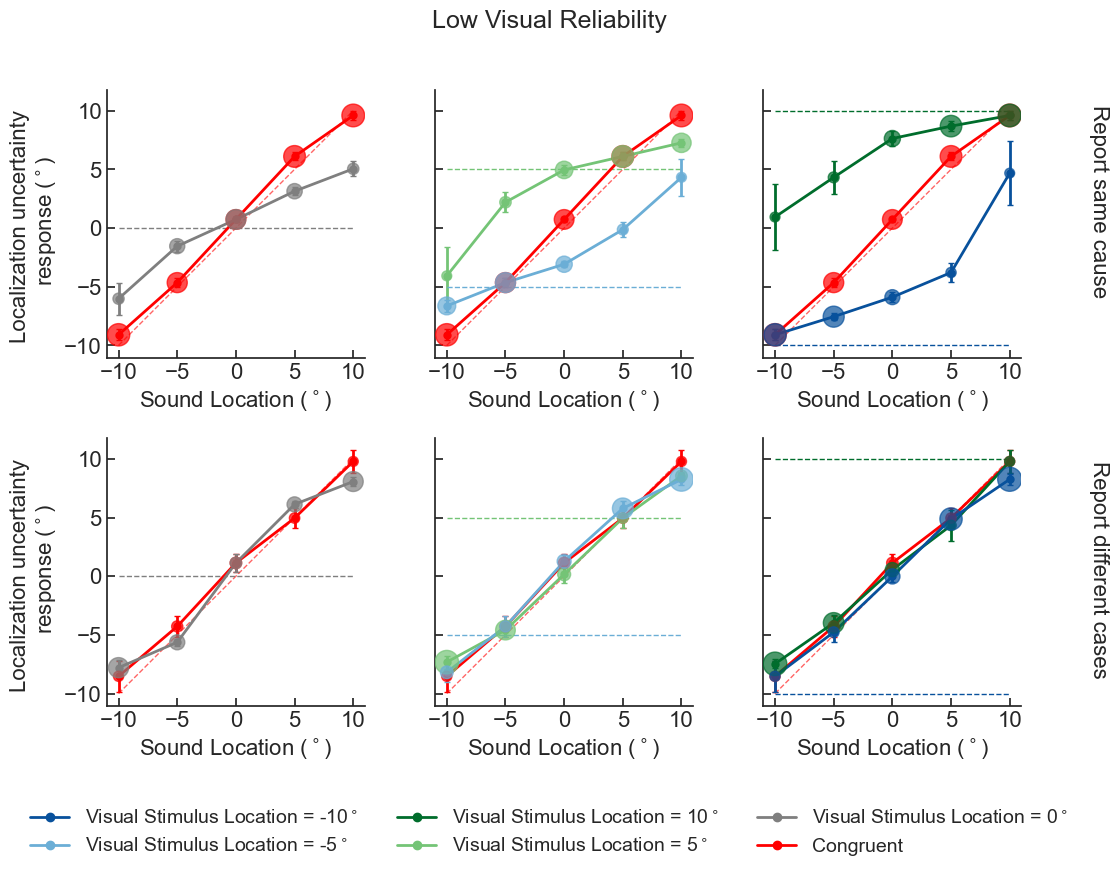

In [ ]:
# compute the cross-condition counts min and max for scaling function
global_min, global_max = get_global_min_max(df=df_beh, groupvar = ["AudLoc", "VisLoc"])

for vrel in ['High', 'Low']:
    fig, axs = plt.subplots(
        nrows=2, ncols=3,
        figsize=(12, 8),
        sharey=True,
        gridspec_kw={'wspace':0.2, 'hspace': 0.3}
    )

    for row, sources in enumerate([1, 2]):
        for col, visloc in enumerate([0, 5, 10]):
            plot_raw_rep_all(
                df=df_beh.loc[df_beh.Sources == sources],
                rel=vrel,
                ax=axs[row, col],
                visloc=visloc,
                #resp_var='CISize',
                legend=False,
                palette=palette_vloc,
                scale = True,
                global_min=global_min,
                global_max = global_max,
                power=2
            )


    legend_elements = [
        Line2D(
            [0], [0],
            color=palette_vloc[vloc],
            lw=2,
            marker='o',
            markersize=6,
            markerfacecolor=palette_vloc[vloc],
            markeredgecolor=palette_vloc[vloc],
            label=f"Visual Stimulus Location = {vloc}$^\\circ$"
        )
        for vloc in [-10, -5, 10, 5, 0]
    ]
    legend_elements.append(
                       Line2D(
                        [0], [0],
                        color='red',
                        lw=2,
                        marker='o',
                        markersize=6,
                        markerfacecolor='red',
                        markeredgecolor='red',
                        label="Congruent",
                    ))
    fig.legend(
        handles=legend_elements,
        title='',
        frameon=False,
        ncol=3,
        fontsize=fontsize-2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )
    
    fig.suptitle(f'{vrel} Visual Reliability', fontsize=fontsize+2)

    axs[1,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
    axs[0,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)

    fig.text(
        0.95, 0.74, 'Report same cause',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    fig.text(
        0.95, 0.28, 'Report different cases',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )
    #fig.supylabel('Auditory Response Location', fontsize=fontsize)
    plt.savefig(os.path.join(plot_path,'Raw_loc', f'Allsub_raw_re_plot_vis_{vrel}.png'), bbox_inches='tight', dpi=300)

## 2.Localization uncertainty estimate

### by spatial disparity

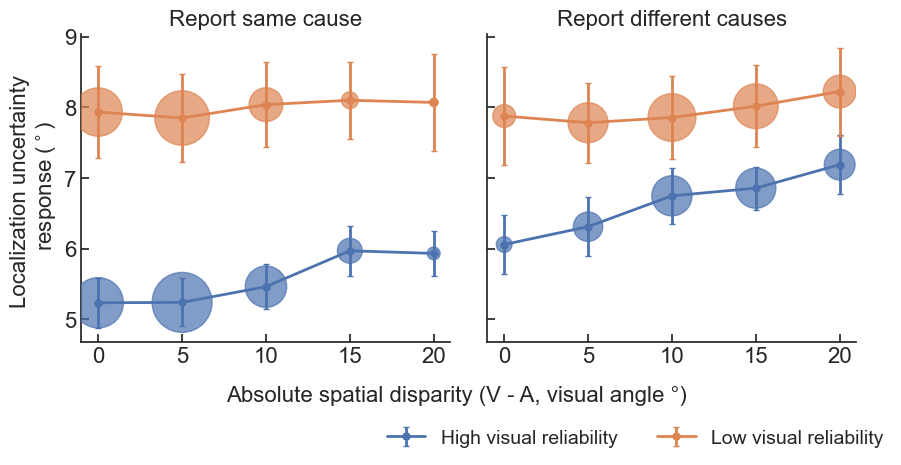

In [ ]:
global_min, global_max = get_global_min_max(df=df_beh, groupvar = ["abs_delta_VA"])
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==1], ax=axs[0])
plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==2], ax=axs[1], legend=True)
# plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==1], ax=axs[0], scale=True, global_min=global_min, global_max=global_max, power=2)
# plot_CI_size_by_disp(df=df_beh.loc[df_beh.Sources==2], ax=axs[1], legend=True, scale=True, global_min=global_min, global_max=global_max, power=2)
axs[0].set_title('Report same cause', fontsize=fontsize)
axs[1].set_title('Report different causes', fontsize=fontsize)
fig.supxlabel('Absolute spatial disparity (V - A, visual angle \u00B0)', fontsize=fontsize, y=-0.05)
axs[0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'conf_inter', 'Allsub_ci_by_causal_disp.png'), bbox_inches='tight', dpi=300)

### by A locations 

m:\1confiProj\scripts\plot_function.py:305: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
m:\1confiProj\scripts\plot_function.py:318: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


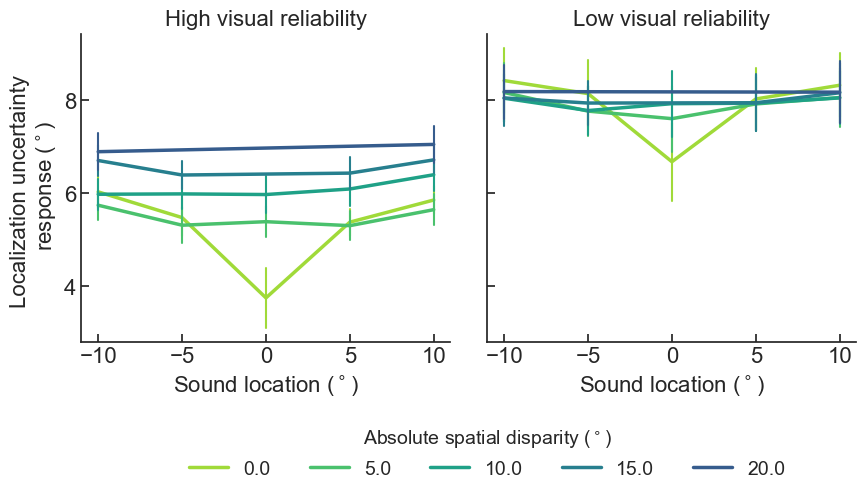

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_condition(df=df_beh, axs=axs) 
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
#fig.supxlabel('Auditory Stimulus location ($^\\circ$)', fontsize=fontsize,y=-0.05)
plt.savefig(os.path.join(plot_path, 'conf_inter', 'Allsub_ci_by_causal_disp_and_audloc.png'), bbox_inches='tight', dpi=300)

### the variability of confidence for common congruent trials

In [ ]:
df_plot = df_beh[(df_beh['Modality'] == 'A')&(df_beh.Sources==1)&(df_beh.AudLoc==df_beh.VisLoc)] #congruent common trials
summary = df_plot.groupby(['sub_id', 'VisRelLabel', 'AudLoc']).agg(ci_mean=('CISize', 'mean'), loc_std = ('RespLoc', 'std'), loc_mean = ('RespLoc', 'mean'),ci_std = ('CISize', 'std'), n=('RespLoc', 'size')).reset_index()
summary
#On subject-level, congruent common trials, plot the localization std against the mean uncertainty.  For each subject and each visual reliability, one location. , 

,sub_id,VisRelLabel,AudLoc,ci_mean,loc_std,loc_mean,ci_std,n
0,2,High,-10.0,5.187353,0.838787,-8.266176,1.646037,34
1,2,High,-5.0,4.175926,0.627923,-4.612222,0.901065,27
2,2,High,0.0,2.965294,0.510003,-0.079412,1.923725,34
3,2,High,5.0,4.877097,0.834609,4.839355,0.994723,31
4,2,High,10.0,5.123714,0.962913,8.224286,1.455117,35
...,...,...,...,...,...,...,...,...
75,25,Low,-10.0,12.180263,0.967807,-7.362368,2.225469,38
76,25,Low,-5.0,9.425000,1.079271,-4.824687,1.820030,32
77,25,Low,0.0,4.525714,2.051413,0.205429,4.183558,35
78,25,Low,5.0,10.222162,0.936040,5.622703,1.475830,37


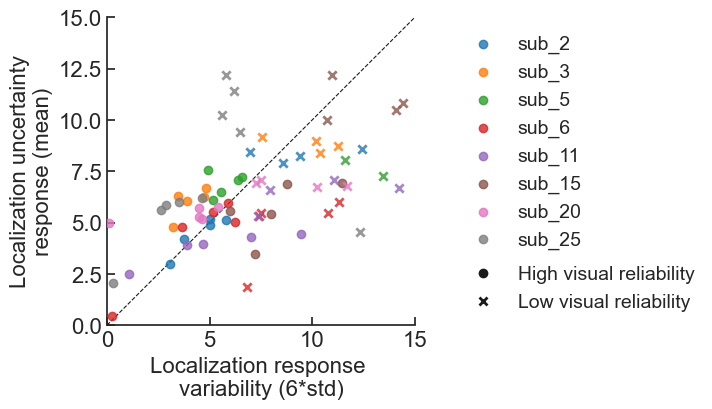

In [ ]:
palette = sns.color_palette("tab10", n_colors=len(ev.dh.sub_lst_all))
color_map = dict(zip(ev.dh.sub_lst_all, palette))

fig, ax = plt.subplots(figsize=(10, 4))

for sub_id in ev.dh.sub_lst_all:
    data = summary[summary["sub_id"] == sub_id].copy()
    data['loc_std'] = data['loc_std'] * 6 # to make it a square

    ax.scatter(
        data.loc[data.VisRelLabel=='High', "loc_std"],
        data.loc[data.VisRelLabel=='High', "ci_mean"],
        #s=data.loc[data.VisRelLabel=='High', "n"],
        color=color_map[sub_id],
        alpha=0.8,
        marker='o',
        zorder=3,
        label=f"sub_{sub_id}"
    )
    ax.scatter(
        data.loc[data.VisRelLabel=='Low', "loc_std"],
        data.loc[data.VisRelLabel=='Low', "ci_mean"],
        #s=data.loc[data.VisRelLabel=='Low', "n"],
        alpha=0.8,
        marker='x',
        color=color_map[sub_id],
        linewidth=2,
        zorder=4,
        #label=f"sub_{sub_id}"
    )

ax.set_xlabel("Localization response \nvariability (6*std)", fontsize=fontsize)
ax.set_ylabel(
    "Localization uncertainty\nresponse (mean)",
    fontsize=fontsize
)

ax.plot([0, 15], [0, 15], "--k", lw=0.8)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim([0, 15])
ax.set_ylim([0, 15])
clean_axs(ax)

# Subject legend (colors)
leg1 = ax.legend(
    bbox_to_anchor=(1.1, 1),
    loc="upper left",
    frameon=False,
    fontsize=fontsize-2,
)

# Reliability legend (markers)
reliability_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='k',
        linestyle='None',
        markersize=6,
        label='High visual reliability'
    ),
    Line2D(
        [0], [0],
        marker='x',
        color='k',
        linestyle='None',
        markersize=6,
        markeredgewidth=2,
        label='Low visual reliability'
    )
]

leg2 = ax.legend(
    handles=reliability_handles,
    bbox_to_anchor=(1.1, 0.25),
    loc="upper left",
    frameon=False,
    fontsize=fontsize-2,
    #title="Visual reliability"
)

# keep both legends
ax.add_artist(leg1)

plt.savefig(os.path.join(plot_path, 'ci_mean_loc_var_rel.png'), bbox_inches='tight', dpi=300)
plt.show()

## 3. Causal confidence

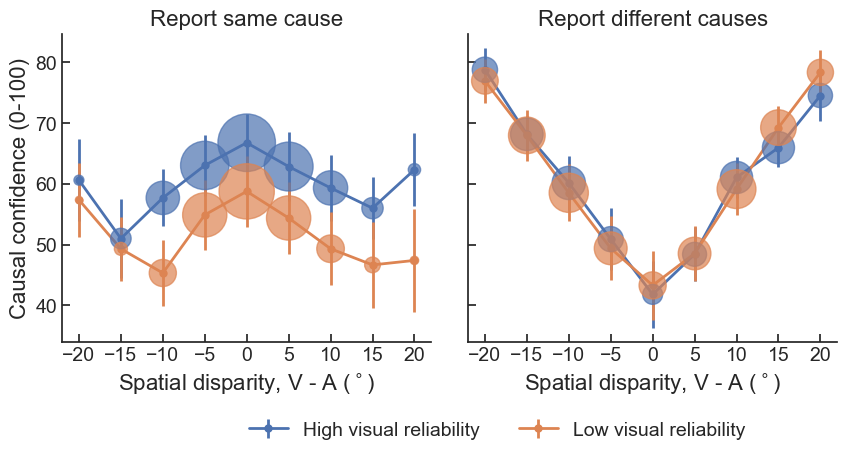

In [ ]:
fig, axs = plt.subplots(figsize=(10, 4), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.1}
                        )
plot_casual_conf(df=df_beh.loc[df_beh.Sources==1],ax=axs[0], 
                 #trial_type='A', 
                 leg=False)
plot_casual_conf(df=df_beh.loc[df_beh.Sources==2],ax=axs[1], 
                 #trial_type='A', 
                 leg=True)

axs[0].set_title('Report same cause', fontsize=fontsize, y=1)
axs[1].set_title('Report different causes', fontsize=fontsize, y=1)
axs[0].set_ylabel('Causal confidence (0-100)', fontsize=fontsize)
fig.savefig(os.path.join(plot_path, "causal_conf_beh.png"), dpi=300, bbox_inches="tight")

### the relationship between perceptual and causal confidence

In [3]:
from scipy.stats import zscore
df_plot = df_beh[(df_beh['Modality'] == 'A')].copy()
#df_plot = df_beh[(df_beh['Modality'] == 'A')&(df_beh.Sources==1)&(df_beh.AudLoc==df_beh.VisLoc)] #congruent common trials

# Standardize data relative to each subject's individual mean/std
df_plot['CISize_z'] = df_plot.groupby('sub_id')['CISize'].transform(zscore)
df_plot['ConfLevel_z'] = df_plot.groupby('sub_id')['ConfLevel'].transform(zscore)

summary = df_plot.groupby(['sub_id', 'VisRelLabel', 'delta_VA', 'Sources']).agg(
    ci_mean=('CISize', 'mean'), 
    cc_std = ('ConfLevel', 'std'), 
    cc_mean = ('ConfLevel', 'mean'),
    ci_std = ('CISize', 'std'), 
    n=('RespLoc', 'size'),
    ci_cv=('CISize', lambda x: x.std() / x.mean() if x.mean() != 0 else np.nan),
    cc_cv=('ConfLevel', lambda x: x.std() / x.mean() if x.mean() != 0 else np.nan),
    ci_zscore = ('CISize_z', 'mean'),
    cc_zscore = ('ConfLevel_z', 'mean')).reset_index()
#summary['Sources']=1
#On subject-level, congruent common trials, plot the localization std against the mean uncertainty.  For each subject and each visual reliability, one location. , 

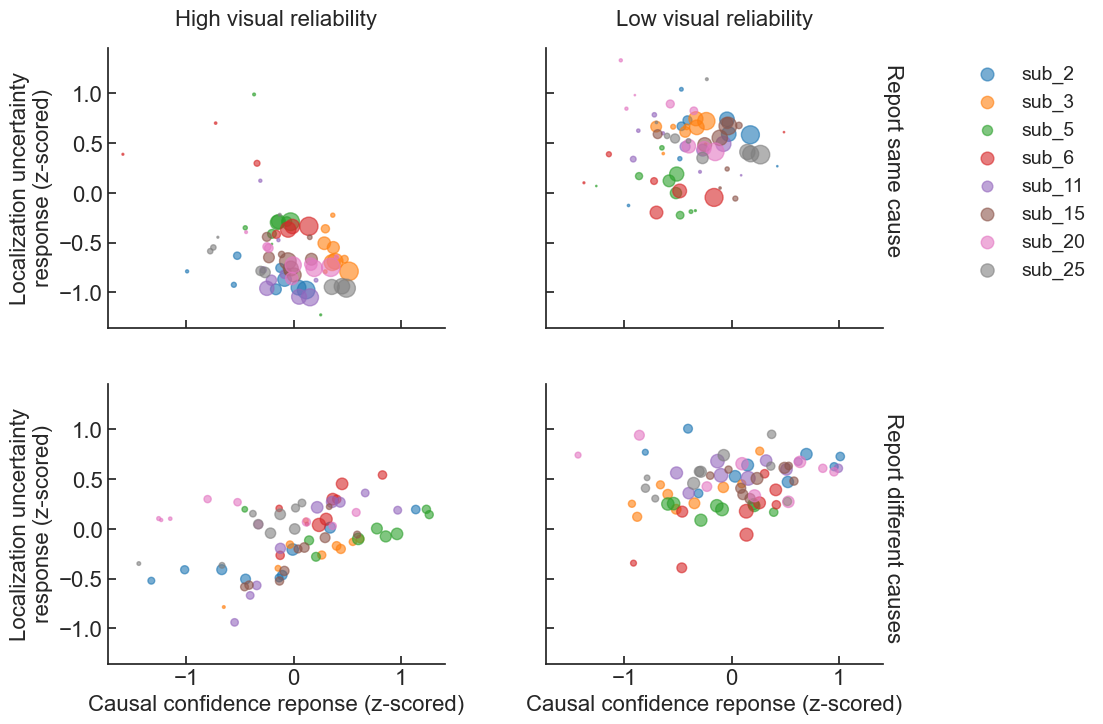

In [4]:
fig, axs = plt.subplots(
    nrows=2, ncols=2,
    sharey=True,
    sharex=True,
    figsize=(10, 8),
    gridspec_kw={'hspace':0.2, 'wspace':0.3}
)

xvar, xlabel = 'cc_zscore', 'Causal confidence reponse (z-scored)'
y_var, ylabel = 'ci_zscore', 'Localization uncertainty\nresponse (z-scored)'
# Generate color palette mapping
# palette = sns.color_palette("colorblind", n_colors=len(ev.dh.sub_lst_all))
# color_map = dict(zip(ev.dh.sub_lst_all, palette))

palette = sns.color_palette("tab10", n_colors=len(ev.dh.sub_lst_all))
color_map = dict(zip(ev.dh.sub_lst_all, palette))

# 2. Plotting loop
for sub_id in ev.dh.sub_lst_all:
    sub_data = summary[summary["sub_id"] == sub_id]

    for col, vis_rel in enumerate(["High", "Low"]):
        for row, sour in enumerate([1, 2]):
            data = sub_data[(sub_data["VisRelLabel"] == vis_rel) & (sub_data["Sources"] == sour)]

            axs[row, col].scatter(
                data[xvar],
                data[y_var],
                s=data["n"],
                color=color_map[sub_id],
                alpha=0.6,
                zorder=3,
                label=f"sub_{sub_id}"
            )

# 3. Corrected Formatting Loops (Explicitly iterating through rows and columns)
titles = ["High visual reliability", "Low visual reliability"]
y_labels = ["Same", "Different"] # Adjust labels if needed

for row in range(2):
    for col in range(2):
        # Apply your cleaning function safely to every axis
        clean_axs(axs[row, col]) 
        
        # Set X-labels only for the bottom row to prevent overlaps
        if row == 1:
            axs[row, col].set_xlabel(xlabel, fontsize=fontsize)
            
        # Set Titles only for the top row
        if row == 0:
            axs[row, col].set_title(titles[col], fontsize=fontsize, y=1.05)

# Set Y-labels cleanly on the leftmost subplots
for ax in axs[:,0]:
    ax.set_ylabel(ylabel,
            fontsize=fontsize)
# axs[0, 0].set_ylabel(f"{y_labels[0]}\nLocalization uncertainty (mean)", fontsize=fontsize)
# axs[1, 0].set_ylabel(f"{y_labels[1]}\nLocalization uncertainty (mean)", fontsize=fontsize)

# 4. Global legend handled outside the plot boundary
axs[0, 1].legend(
    title="",
    bbox_to_anchor=(1.2, 1),
    loc="upper left",
    frameon=False,
    fontsize=fontsize-2
)

fig.text(
        0.9, 0.74, 'Report same cause',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

fig.text(
    0.9, 0.28, 'Report different causes',
    va='center', ha='left',
    fontsize=fontsize, rotation=270
)
# Use bbox_inches="tight" during save to prevent cutting off the legend
fig.savefig(os.path.join(plot_path, "cc_ci_relation.png"), dpi=300, bbox_inches="tight")
plt.show()


# Model simulation analysis

## 1. Localization raw data

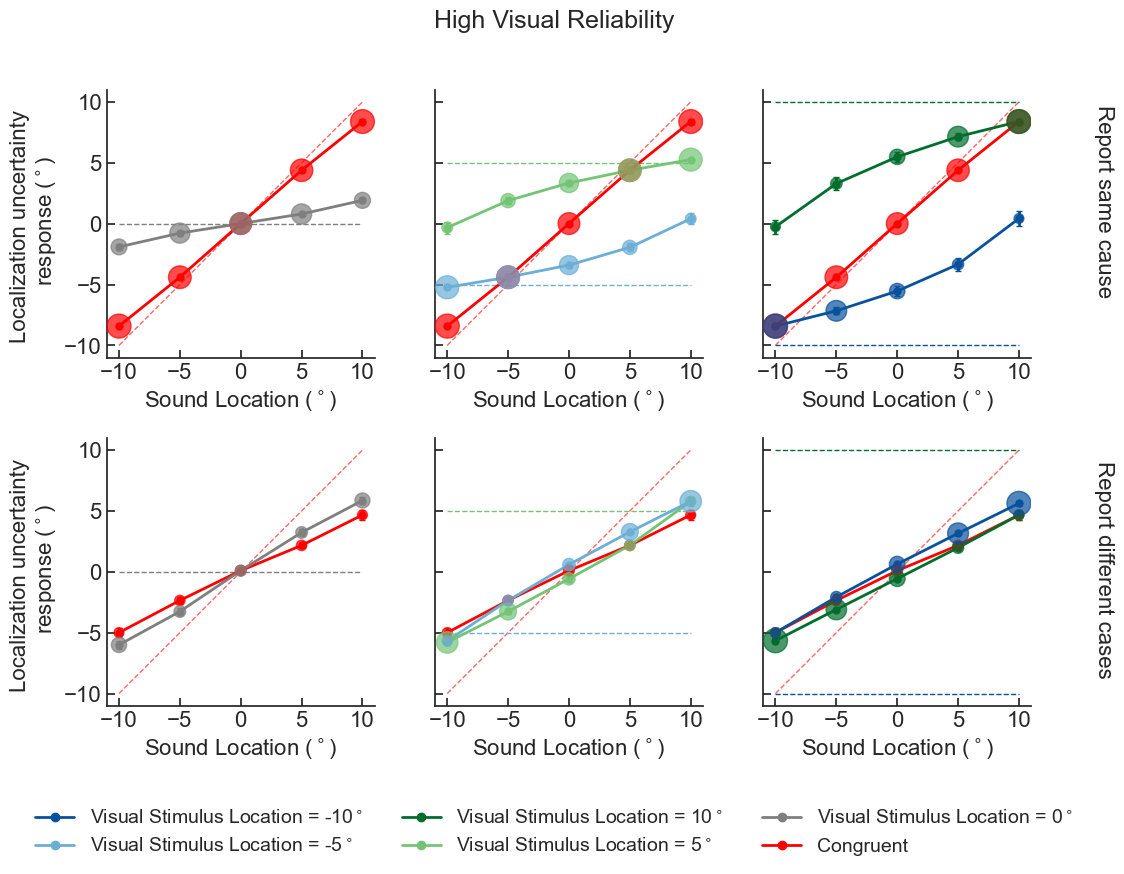

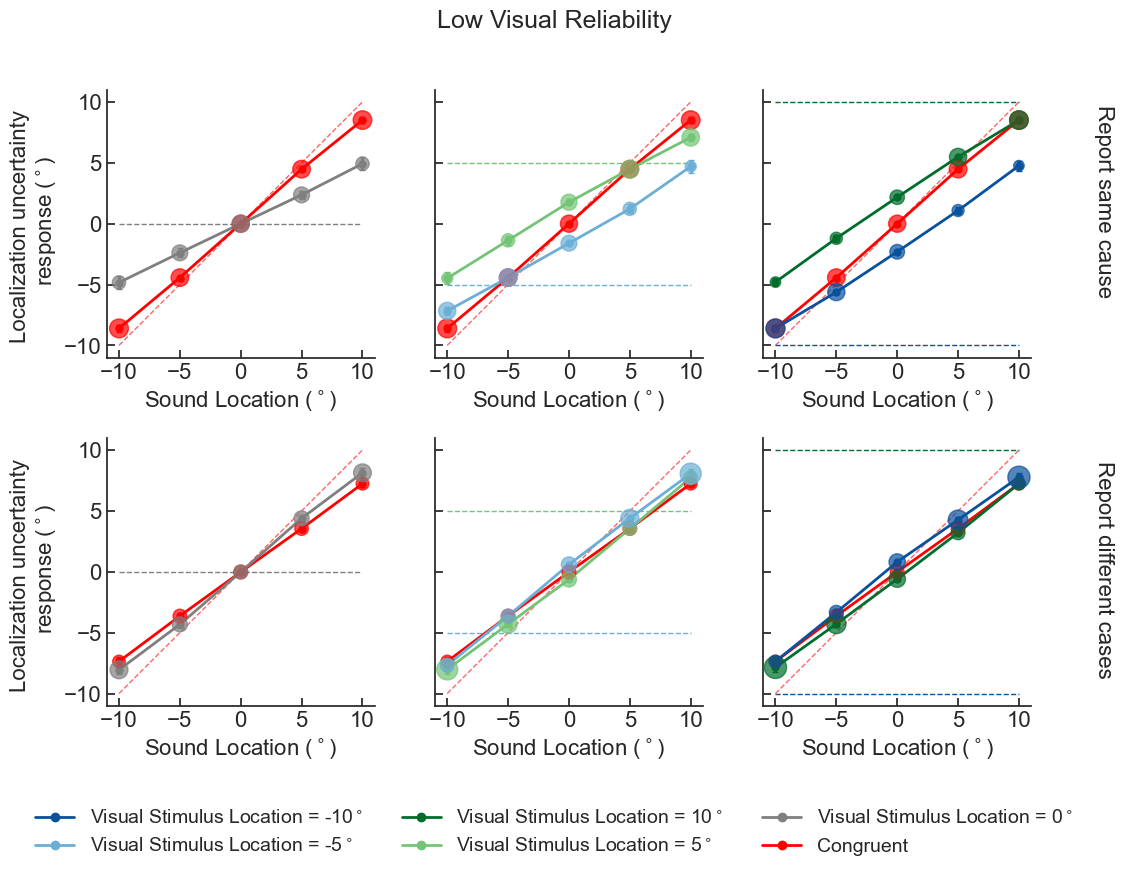

In [3]:
# compute the cross-condition counts min and max for scaling function
global_min, global_max = get_global_min_max(df=df_sim, groupvar = ["AudLoc", "VisLoc"])

for vrel in ['High', 'Low']:
    fig, axs = plt.subplots(
        nrows=2, ncols=3,
        figsize=(12, 8),
        sharey=True,
        gridspec_kw={'wspace':0.2, 'hspace': 0.3}
    )

    for row, sources in enumerate([1, 2]):
        for col, visloc in enumerate([0, 5, 10]):
            plot_raw_rep_all(
                df=df_sim.loc[df_sim.Sources == sources],
                rel=vrel,
                ax=axs[row, col],
                visloc=visloc,
                #resp_var='CISize',
                legend=False,
                palette=palette_vloc,
                scale = True,
                global_min=global_min,
                global_max = global_max,
                power=2
            )


    legend_elements = [
        Line2D(
            [0], [0],
            color=palette_vloc[vloc],
            lw=2,
            marker='o',
            markersize=6,
            markerfacecolor=palette_vloc[vloc],
            markeredgecolor=palette_vloc[vloc],
            label=f"Visual Stimulus Location = {vloc}$^\\circ$"
        )
        for vloc in [-10, -5, 10, 5, 0]
    ]
    legend_elements.append(
                       Line2D(
                        [0], [0],
                        color='red',
                        lw=2,
                        marker='o',
                        markersize=6,
                        markerfacecolor='red',
                        markeredgecolor='red',
                        label="Congruent",
                    ))
    fig.legend(
        handles=legend_elements,
        title='',
        frameon=False,
        ncol=3,
        fontsize=fontsize-2,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.1)
    )
    
    fig.suptitle(f'{vrel} Visual Reliability', fontsize=fontsize+2)

    axs[1,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
    axs[0,0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)

    fig.text(
        0.95, 0.74, 'Report same cause',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )

    fig.text(
        0.95, 0.28, 'Report different cases',
        va='center', ha='left',
        fontsize=fontsize, rotation=270
    )
    #fig.supylabel('Auditory Response Location', fontsize=fontsize)
    plt.savefig(os.path.join(plot_path,'models', f'M_raw_re_plot_vis_{vrel}.png'), bbox_inches='tight', dpi=300)

## 2.Localization uncertainty estimate

### by spatial disparity

In [12]:
# QUICK ADHOC TO SEE HOW MUCH THE TRIAL SCALES
sim_min, sim_max = get_global_min_max(df=df_sim, groupvar=['abs_delta_VA', 'sub_id'], modality='A')
beh_min, beh_max = get_global_min_max(df=df_beh, groupvar=['abs_delta_VA', 'sub_id'], modality='A')
sim_max/beh_max

np.float64(26.225454545454546)

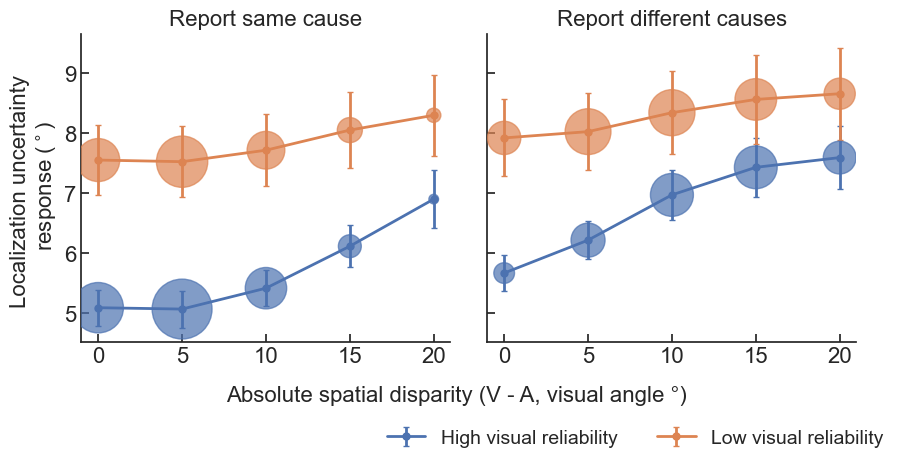

In [11]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_disp(df=df_sim.loc[df_sim.Sources==1], ax=axs[0], scale=True, k=26)
plot_CI_size_by_disp(df=df_sim.loc[df_sim.Sources==2], ax=axs[1], legend=True, scale=True, k=26)
axs[0].set_title('Report same cause', fontsize=fontsize)
axs[1].set_title('Report different causes', fontsize=fontsize)
fig.supxlabel('Absolute spatial disparity (V - A, visual angle \u00B0)', fontsize=fontsize, y=-0.05)
axs[0].set_ylabel('Localization uncertainty \n response ($^\\circ$)', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'models', 'M_ci_by_causal_disp.png'), bbox_inches='tight', dpi=300)

### by A locations 

m:\1confiProj\scripts\plot_function.py:323: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(
m:\1confiProj\scripts\plot_function.py:336: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


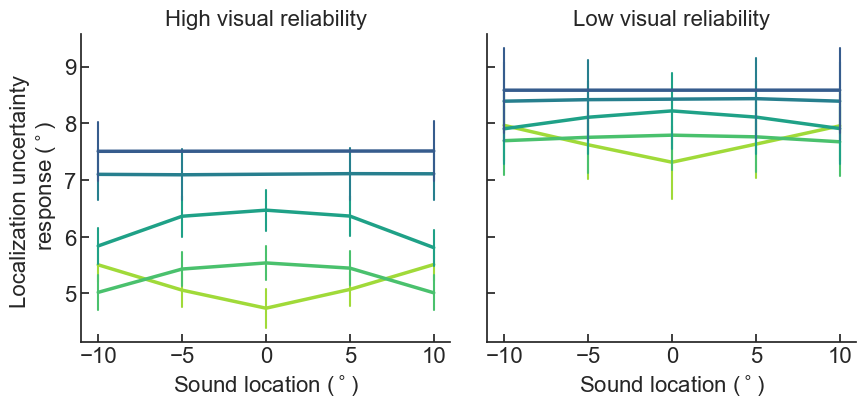

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True, gridspec_kw={'wspace': 0.1})
plot_CI_size_by_condition(df=df_sim, m_id=2, axs=axs) 
axs[1].get_legend().remove()
axs[0].set_title('High visual reliability', fontsize=fontsize)
axs[1].set_title('Low visual reliability', fontsize=fontsize)
plt.savefig(os.path.join(plot_path, 'models', 'M_ci_by_causal_disp_and_audloc.png'), bbox_inches='tight', dpi=300)

## 3. Causal confidence

In [14]:
# QUICK ADHOC TO SEE HOW MUCH THE TRIAL SCALES
sim_min, sim_max = get_global_min_max(df=df_sim, groupvar=['delta_VA', 'sub_id'], modality='A')
beh_min, beh_max = get_global_min_max(df=df_beh, groupvar=['delta_VA', 'sub_id'], modality='A')
sim_max/beh_max

np.float64(26.820224719101123)

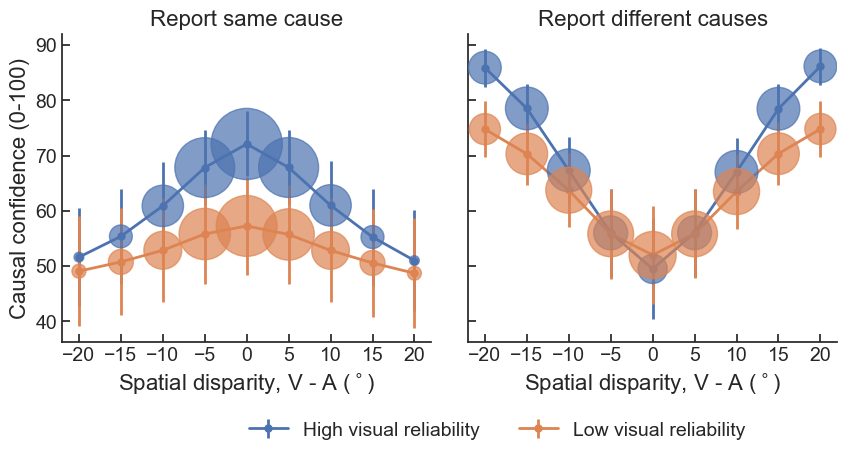

In [15]:
fig, axs = plt.subplots(figsize=(10, 4), ncols=2, nrows=1, sharey=True,
                        gridspec_kw={'wspace': 0.1}
                        )
plot_casual_conf(df=df_sim.loc[df_sim.Sources==1],ax=axs[0], 
                 #trial_type='A', 
                 scale=True,
                 k=26,
                 leg=False)
plot_casual_conf(df=df_sim.loc[df_sim.Sources==2],ax=axs[1], 
                 #trial_type='A', 
                 scale=True,
                 k=26,
                 leg=True)

axs[0].set_title('Report same cause', fontsize=fontsize, y=1)
axs[1].set_title('Report different causes', fontsize=fontsize, y=1)

axs[0].set_ylabel('Causal confidence (0-100)', fontsize=fontsize)
fig.savefig(os.path.join(plot_path, 'models', "M_causal_conf.png"), dpi=300, bbox_inches="tight")

## 4.Formal model comparison

In [ ]:
exp_name1, exp_name2 = 'test_causal_bin1', 'with_dn'
CM=CompareModels(exp_name1, exp_name2)
m_lst= [2]

In [ ]:
df_ev, df_best_model = CM.compare_models(m1_list=m_lst, m2_list=m_lst, best_by='BIC', by_nll='train')

In [ ]:
df_ev

,m_id,exp,sub_id,AIC,AICc,BIC,nll,npar,best_par,nll_method,CI_readout,est_var,Causal_readout
0,2,test_causal_bin1,2,37568.566724,37568.738785,37649.854774,18770.283362,14,"[1.326134351452349, 4.650853633880615, 4.64873...",QML,BayInt,MS,Bay
1,2,test_causal_bin1,3,35324.544129,35324.719202,35405.590695,17648.272065,14,"[1.0045600873260956, 3.6532156467437744, 5.579...",QML,BayInt,MS,Bay
2,2,test_causal_bin1,5,35605.052149,35605.226930,35686.121893,17788.526074,14,"[1.7991667350174971, 4.258444547653198, 3.9422...",QML,BayInt,MS,Bay
3,2,test_causal_bin1,6,34258.787898,34258.962680,34339.857643,17115.393949,14,"[1.4439854756012767, 1.755759835243225, 3.3877...",QML,BayInt,MS,Bay
4,2,test_causal_bin1,11,35646.966846,35647.141409,35728.053949,17809.483423,14,"[1.079057272269894, 3.7007843255996704, 4.2345...",QML,BayInt,MS,Bay
5,2,test_causal_bin1,15,38115.504884,38115.676733,38196.810024,19043.752442,14,"[0.5902048433094178, 6.306135773658752, 6.2475...",QML,BayInt,MS,Bay
6,2,test_causal_bin1,20,34270.218675,34270.394775,34351.183811,17121.109337,14,"[0.9323276798160927, 2.7525576651096344, 5.001...",QML,BayInt,MS,Bay
7,2,test_causal_bin1,25,39009.191750,39009.364518,39090.422680,19490.595875,14,"[0.45784243104317845, 1.666839599609375, 4.490...",QML,BayInt,MS,Bay
8,2,with_dn,2,35779.248434,35779.445155,35866.342773,17874.624217,15,"[2.021700377847035, 6.817628875374794, 5.20707...",QML,BayInt,MS,Bay
9,2,with_dn,3,35409.843480,35410.043647,35496.679086,17689.921740,15,"[3.508105432502043, 6.77004337310791, 5.177550...",QML,BayInt,MS,Bay


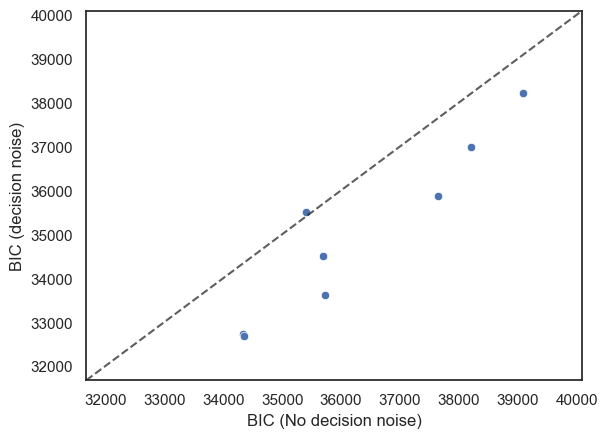

In [ ]:
# two models comparison plot BIC aganist BIC
sns.scatterplot(x=df_ev.loc[(df_ev.m_id==m_lst[0]) & (df_ev.exp==exp_name1), 'BIC'].reset_index(drop=True), y=df_ev.loc[(df_ev.m_id==m_lst[0]) & (df_ev.exp==exp_name2), 'BIC'].reset_index(drop=True))
lims = [
    df_ev.BIC.min()-1000,  # lowest value across both
    df_ev.BIC.max()+1000   # highest value across both
]
plt.xlim(lims)
plt.ylim(lims)

# Add diagonal y=x line
plt.plot(lims, lims, 'k--', alpha=0.7)

plt.xlabel("BIC (No decision noise)")
plt.ylabel("BIC (decision noise)")

plt.show()